In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [18]:
df1 = pd.read_csv('../ncbi_562_data.csv')
df2 = pd.read_csv('../ncbi_590_data.csv')
df1 = df1[df1['is_usa_based'] == 1]
df1['collection_year'] = pd.to_numeric(df1['collection_year'], errors='coerce')
df1 = df1[df1['collection_year'] >= 2005]
df1 = df1[df1['month'].notna()]
df1['collection_year'] = df1['collection_year'].astype(str)
df1['collection_year'] = df1['collection_year'].str[:4]
df1['month'] = df1['month'].astype(int)
df1['month'] = df1['month'].apply(lambda x: f"{x:02d}")
df1['year_and_month'] = df1['collection_year'] + '-' + df1['month']

df2 = df2[df2['is_usa_based'] == 1]
df2['collection_year'] = pd.to_numeric(df2['collection_year'], errors='coerce')
df2 = df2[df2['collection_year'] >= 2005]
df2 = df2[df2['month'].notna()]
df2['collection_year'] = df2['collection_year'].astype(str)
df2['collection_year'] = df2['collection_year'].str[:4]
df2['month'] = df2['month'].astype(int)
df2['month'] = df2['month'].apply(lambda x: f"{x:02d}")
df2['year_and_month'] = df2['collection_year'] + '-' + df2['month']

C:\Users\bryan\AppData\Local\Temp\ipykernel_23208\4100235165.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('../ncbi_590_data.csv')


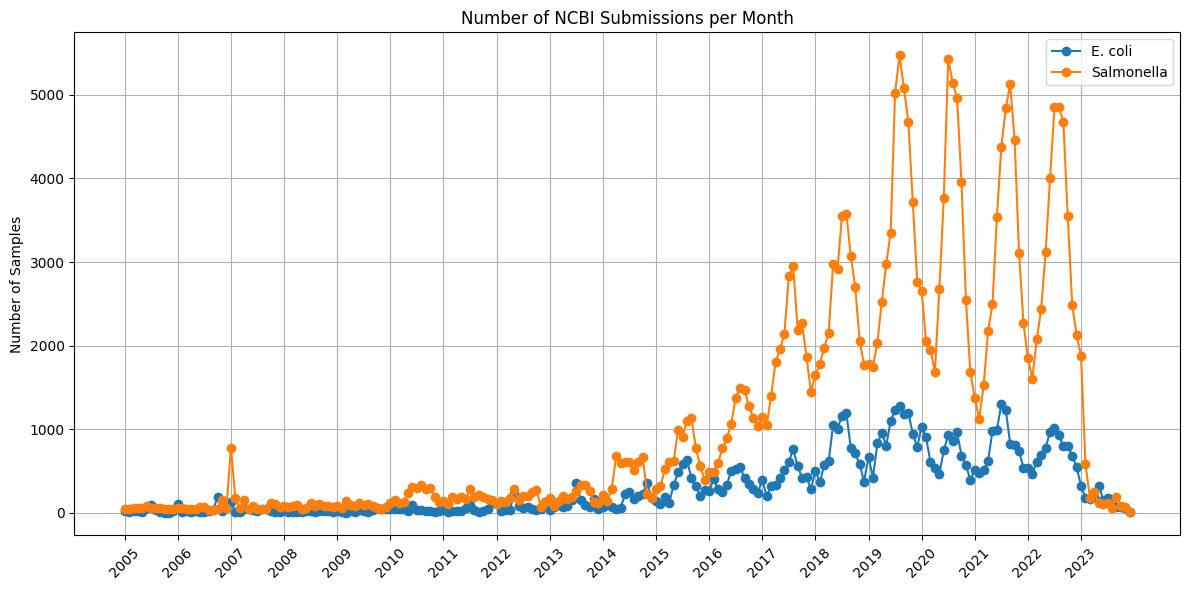

In [23]:
#make a line plot of the value_counts of year_and_month. Put both dataframes on the same plot
year_month_counts1 = df1['year_and_month'].value_counts().sort_index()
year_month_counts2 = df2['year_and_month'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
year_month_counts1.plot(kind='line', marker='o', label='E. coli')
year_month_counts2.plot(kind='line', marker='o', label='Salmonella')
plt.title('Number of NCBI Submissions per Month')
plt.ylabel('Number of Samples')
#erase the x-axis label
plt.xlabel('')
labels = [label.replace('-01', '') for label in year_month_counts1.index[::12]]
plt.xticks(ticks=range(0, len(year_month_counts1), 12), labels=labels, rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('seasonal_ncbi_526_590.png')
plt.show()

In [16]:
#Similar to the NORS data, we see seasonal peaks during the summer months, and lows during winter months.